In [1]:
import numpy as np
from negf import gf_dense,bse_dense
from wannier import wannierham
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
nb=14
nx=21
ny=1
nz=1

hr,wannier_center,n_range,cell,L = wannierham.load_from_file(fname='ham_dat',lreorder_axis=False,axis=[1,2,3],nb=nb,nx=nx,ny=ny,nz=nz)

Lz=L[2]
Ly=L[1]
Lx=L[0]

ns = 2
length = 6 
nen = 500
nsub = 5
nky=1
nkz=1
nk=nky*nkz
niter=0
eps_screen=1.0
r0=3.0
emin=-10.0
emax=4.0

v = np.zeros((nb*length,nb*length,nk), dtype='complex')  
ham = np.zeros((nb*length,nb*length,nk), dtype='complex')  

h00,h10 = wannierham.block_mat_def(kx=0.0, ky=0.0, kz=0.0,nb=nb,ns=ns,n_range=n_range,hr=hr,cell=cell)
ham[:,:,0] = wannierham.full_device_mat_def(ky=0.0,kz=0.0,nb=nb,ns=ns,length=length,hr=hr,cell=cell,n_range=n_range)
v[:,:,0] = wannierham.full_device_bare_coulomb(ky=0.0,kz=0.0,length=length,eps=eps_screen,r0=r0,ldiag=True,nb=nb,ns=ns,method='pointlike',n_range=n_range,wannier_center=wannier_center,cell=cell)

energies = np.linspace(emin,emax,nen)

dim_lead = np.ones(2)* nb*ns
temp =  np.ones(2)* 7.0
mu = np.array( [-2.85, -2.85] )

siglead = np.zeros((nb*ns,nb*ns,nen,2,nk), dtype='complex')

lead_h10 = np.zeros((nb*ns,nb*ns,2,nk), dtype='complex')
lead_h10[:,:,0,0] = np.transpose( np.conjugate( h10 ) ) 
lead_h10[:,:,1,0] = h10

lead_h00 = np.zeros((nb*ns,nb*ns,2,nk), dtype='complex')
lead_h00[:,:,0,0] = h00
lead_h00[:,:,1,0] = h00

lead_coupling = np.zeros((nb*ns,nb*length,2,nk), dtype='complex')
lead_coupling[0:nb*ns,0:nb*ns,0,0] = lead_h10[:,:,0,0]
lead_coupling[0:nb*ns,nb*(length-ns):nb*length,1,0] = lead_h10[:,:,1,0]



In [3]:


ndiag=nb

G_retarded,G_lesser,G_greater,W0,tr = gf_dense.solve_gw_3d(scba_tol=1e-3,niter=niter,nm_dev=nb*length,lx=Lx,length=length,spindeg=2.0,
                                                    temps=temp[0],tempd=temp[1],mus=mu[0],mud=mu[1],alpha_mix=0.5,
                                                    nen=nen,nsub=nsub,en=energies,nb=nb,ns=ns,nphiy=nky,nphiz=nkz,
                                                    ham=ham,h00lead=lead_h00,h10lead=lead_h10,t=lead_coupling,v=v,
                                                    ndiag=ndiag,num_lead=2,flatband=False,output_files=True)


 ============ green_solve_gw_3D ============
    mus=        -2.8500    mud=        -2.8500
 + iter=           0 error=   1.0000000000000000     
 calc G
   0  IDS=    0.100446E-30    0.266348E-32
 calc P
 calc W
 calc SigGW
 calc G for the last time
   1  IDS=    0.105860E-17   -0.908751E-18


   start computation L0_ijkl = G_jl G_ki ...
   start computation -L0 K
   start invert (I - L0 K)
   start computation L = (I - L0 K) \ L0  


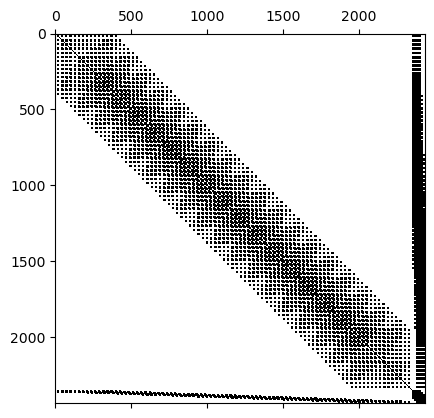

In [4]:
nop=200         
P_retarded1,system1,epsilon1,L1,M1,nn = bse_dense.bse_fullsolve(alpha=0.99,spindeg=2.0,ndiag=ndiag,
                                                                nm_dev=nb*length,nen=nen,nsub=nsub,en=energies,
                                                                nop=nop,nk=nk,g_lesser=G_lesser,
                                                                g_greater=G_greater,g_retarded=G_retarded,
                                                                w=W0[:,:,0],v=v[:,:,0])                                                        
plt.spy(system1)


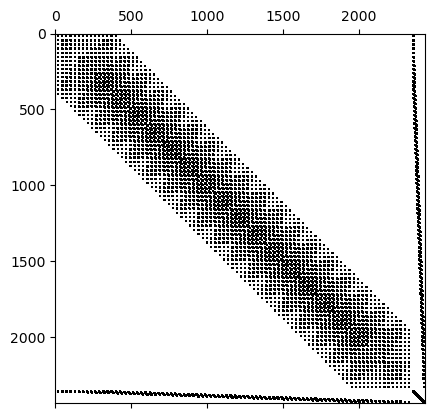

In [5]:
plt.spy(L1)

   start computation L0_ijkl = G_jl G_ki ...
   start computation -L0 K
   start invert (I - L0 K)
   start computation L = (I - L0 K) \ L0  


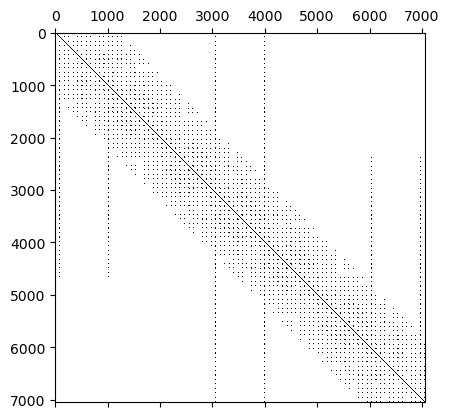

In [6]:
P_retarded2,system2,epsilon2 = bse_dense.bse_fullsolve_orig(alpha=0.99,spindeg=2.0,ndiag=ndiag,
                                                                nm_dev=nb*length,nen=nen,nsub=nsub,en=energies,
                                                                nop=nop,nk=nk,g_lesser=G_lesser,
                                                                g_greater=G_greater,g_retarded=G_retarded,
                                                                w=W0[:,:,0],v=v[:,:,0])                                                        
plt.spy(system2)

In [7]:
print('Max error=', np.max(np.abs(P_retarded1-P_retarded2)))
print('Max element in 1=', np.max(np.abs(P_retarded1)))
print('Max element in 2=', np.max(np.abs(P_retarded2)))

Max error= 1.1188630228279524e-16
Max element in 1= 0.10304616552844738
Max element in 2= 0.1030461655284474


In [9]:
from sdr.lu.lu_factorize import lu_factorize_tridiag_arrowhead
from sdr.lu.lu_selected_inversion import lu_sinv_tridiag_arrowhead
from sdr.lu.lu_solve import lu_slv_tridiag_arrowhead
from sdr.utils import matrix_generation
from sdr.utils.matrix_transform import (cut_to_blocktridiag_arrowhead,
                                        from_arrowhead_arrays_to_dense,
                                        from_dense_to_arrowhead_arrays)
blocksize = nb*length
ndiag = nb

diag blocksize= 336
tip blocksize= 84
number of blocks= 7
ndiag= 14


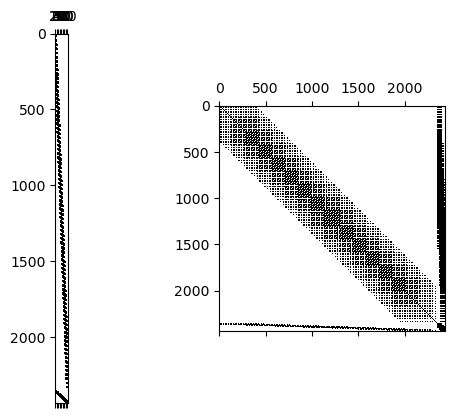

In [10]:
import scipy.linalg as la
A = system1.copy()
L = L1.copy()
diag_blocksize = blocksize*4
arrow_blocksize = blocksize
print('diag blocksize=',diag_blocksize)
print('tip blocksize=',arrow_blocksize)
print('number of blocks=',(A.shape[0]-arrow_blocksize)//diag_blocksize)
print('ndiag=',ndiag)

B = np.zeros((A.shape[0],arrow_blocksize),dtype=A.dtype)
B = L[:,-arrow_blocksize:]
plt.subplot(1,2,1)
plt.spy(B)
plt.subplot(1,2,2)
plt.spy(A)

tip max abs diff= 0.00029395103218219834 / tip max abs Xref= 1.0042663982571691
Max abs diff= 0.0001128212268680735
Max abs ref= 0.10304616552844738
Max abs sdr= 0.10305014681379236


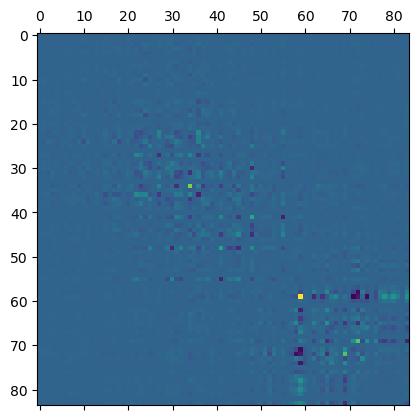

In [11]:


X_ref = la.inv(A)
P_ref = np.fliplr(np.flipud(P_retarded1))
# P_ref = la.solve(A, B)
# P_ref = - 1j* P_ref[-arrow_blocksize:,:]

(
    A_diagonal_blocks,
    A_lower_diagonal_blocks,
    A_upper_diagonal_blocks,
    A_arrow_bottom_blocks,
    A_arrow_right_blocks,
    A_arrow_tip_block,
) = from_dense_to_arrowhead_arrays(A, diag_blocksize, arrow_blocksize)

(
    L_diagonal_blocks,
    L_lower_diagonal_blocks,
    L_arrow_bottom_blocks,
    U_diagonal_blocks,
    U_upper_diagonal_blocks,
    U_arrow_right_blocks,
    P_arrow_tip_blocks
) = lu_factorize_tridiag_arrowhead(
    A_diagonal_blocks,
    A_lower_diagonal_blocks,
    A_upper_diagonal_blocks,
    A_arrow_bottom_blocks,
    A_arrow_right_blocks,
    A_arrow_tip_block,
)

(
    X_sdr_diagonal_blocks,
    X_sdr_lower_diagonal_blocks,
    X_sdr_upper_diagonal_blocks,
    X_sdr_arrow_bottom_blocks,
    X_sdr_arrow_right_blocks,
    X_sdr_arrow_tip_block,
) = lu_sinv_tridiag_arrowhead(
    L_diagonal_blocks,
    L_lower_diagonal_blocks,
    L_arrow_bottom_blocks,
    U_diagonal_blocks,
    U_upper_diagonal_blocks,
    U_arrow_right_blocks,
)

X_sdr_arrow_tip_block = X_sdr_arrow_tip_block @ np.transpose(P_arrow_tip_blocks)

X_sdr = from_arrowhead_arrays_to_dense(
    X_sdr_diagonal_blocks,
    X_sdr_lower_diagonal_blocks,
    X_sdr_upper_diagonal_blocks,
    X_sdr_arrow_bottom_blocks,
    X_sdr_arrow_right_blocks,
    X_sdr_arrow_tip_block,
)

X_diff = np.array(X_ref[-arrow_blocksize:,-arrow_blocksize:]) - X_sdr_arrow_tip_block

print('tip max abs diff=', np.max(np.abs(X_diff)) , '/ tip max abs Xref=', np.max(np.abs(X_ref[-arrow_blocksize:,-arrow_blocksize:])) )

# for i in range((A.shape[0]-arrow_blocksize)//diag_blocksize):
#     X_diff = np.array(X_ref[diag_blocksize*i:diag_blocksize*(i+1),diag_blocksize*i:diag_blocksize*(i+1)]) - X_sdr_diagonal_blocks[:,diag_blocksize*i:diag_blocksize*(i+1)]
#     print(i,'diag block max abs diff=', np.max(np.abs(X_diff)), '/ max abs Xref=', np.max(np.abs(X_sdr_diagonal_blocks[:,diag_blocksize*i:diag_blocksize*(i+1)])) ) 

P_sdr = - 1j* X_sdr @ B
P_diff = P_ref - P_sdr[-arrow_blocksize:,:]

print('Max abs diff=', np.max(np.abs(P_diff)) )
print('Max abs ref=', np.max(np.abs(P_ref)) )
print('Max abs sdr=', np.max(np.abs(P_sdr)) )

plt.matshow(np.imag(P_diff))